In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import medfilt

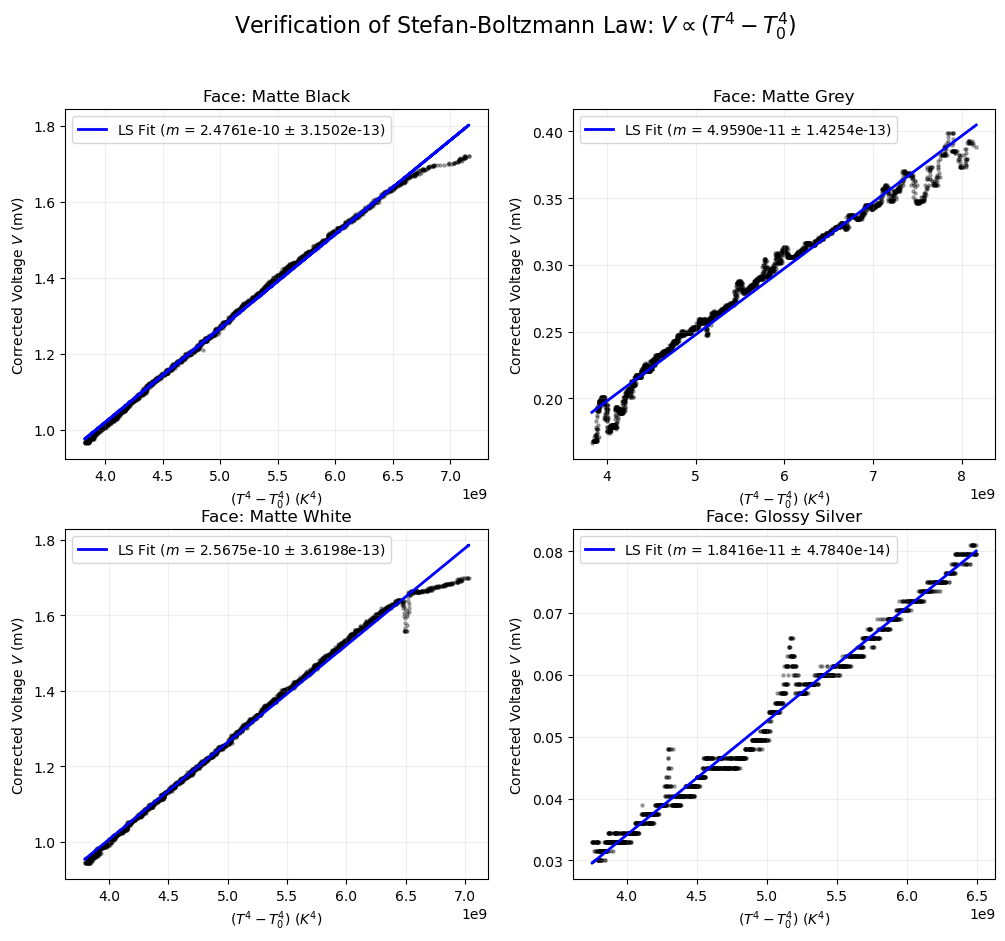


               SB VERIFICATION RESULTS (V vs T^4-T0^4)                
Surface         | Gradient (m)    | ± Uncertainty   | Ratio     
----------------------------------------------------------------------
Matte Black     | 2.4761e-10      | 3.1502e-13      | 0.9644    
Matte Grey      | 4.9590e-11      | 1.4254e-13      | 0.1931    
Matte White     | 2.5675e-10      | 3.6198e-13      | 1.0000    
Glossy Silver   | 1.8416e-11      | 4.7840e-14      | 0.0717    



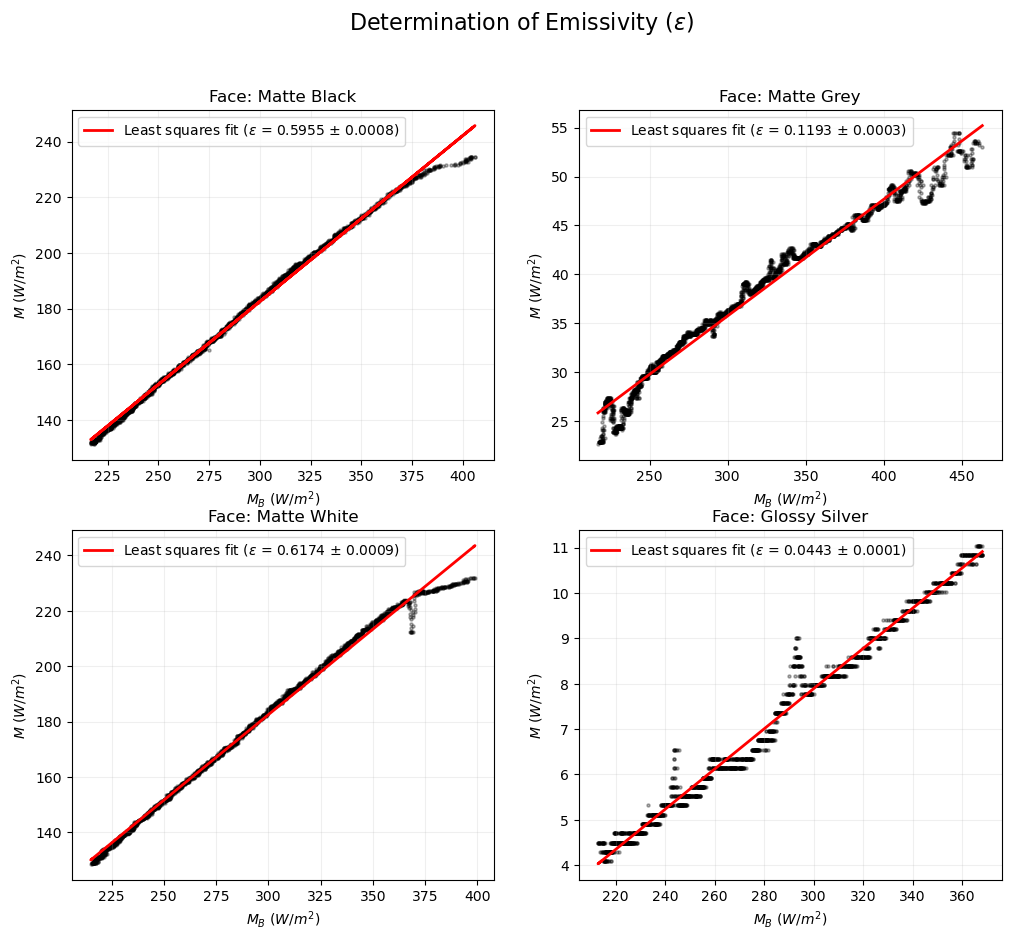


             FINAL EMISSIVITY RESULTS (ε)              
Surface         | Emissivity (ε)  | Uncertainty (±)
-------------------------------------------------------
Matte Black     | 0.59547            | 0.00076
Matte Grey      | 0.11926            | 0.00034
Matte White     | 0.61745            | 0.00087
Glossy Silver   | 0.04429            | 0.00012


In [59]:
# --- 1. Functions ---

def get_f12_sim(r1, r2, d):
    """Calculates view factor from disk 1 to disk 2."""
    X = 1 + (d**2 / r1**2) + (r2/r1)**2
    return 0.5 * (X - np.sqrt(X**2 - 4 * (r2/r1)**2))

def linear_least_squares(x, y):
    """Returns: gradient (m), intercept (c), and gradient uncertainty (m_err)."""
    n = len(x)
    x_mean, y_mean = np.mean(x), np.mean(y)
    ss_xx = np.sum((x - x_mean)**2)
    ss_xy = np.sum((x - x_mean) * (y - y_mean))
    m = ss_xy / ss_xx
    c = y_mean - m * x_mean
    y_pred = m * x + c
    ss_res = np.sum((y - y_pred)**2)
    s_y = np.sqrt(ss_res / (n - 2))
    m_err = s_y / np.sqrt(ss_xx)
    return m, c, m_err

# --- 2. Geometric Inputs & Constants ---
r_cube_equiv = 5.53  
r_sensor = 0.75      
dist = 9.7           
F_view = get_f12_sim(r_sensor, r_cube_equiv, dist)

sigma = 5.67e-8  
T0 = 23 + 273.15  
sensitivity = 30e-6 
v_offset = -0.009  

files = ["matte black.csv", "matte grey.csv", "matte white.csv", "glossy silver.csv"]
labels = ['Matte Black', 'Matte Grey', 'Matte White', 'Glossy Silver']

# Storage for tables
sb_verification_results = []
emissivity_results = []

# --- 3. Processing & Plotting ---

# Figure 1: Verification
fig1, axes1 = plt.subplots(2, 2, figsize=(12, 10))
fig1.suptitle(r'Verification of Stefan-Boltzmann Law: $V \propto (T^4 - T_0^4)$', fontsize=16)
axes1 = axes1.flatten()


# I need to process everything once to find the maximum gradient for the ratio table
temp_m1_values = []

for i, file in enumerate(files):
    try:
        df = pd.read_csv(file)
        df.columns = ['time', 'temperature', 'voltage']
        df = df.apply(pd.to_numeric, errors='coerce').dropna()
        if labels[i] == 'Glossy Silver':
            df = df[df['temperature'] <= 72]

        df['v_corr'] = (df['voltage'] - v_offset) * -1
        df['v_smooth'] = medfilt(df['v_corr'], kernel_size=11)
        
        T_kelvin = df['temperature'] + 273.15
        T_diff_4 = (T_kelvin**4 - T0**4)
        M_B = sigma * T_diff_4
        M = (df['v_smooth'] * 1e-3) / (sensitivity * F_view)

        # Plot 1: SB Verification
        m1, c1, m1_err = linear_least_squares(T_diff_4, df['v_smooth'])
        sb_verification_results.append({'label': labels[i], 'm': m1, 'err': m1_err})
        
        axes1[i].scatter(T_diff_4, df['v_smooth'], color='black', s=5, alpha=0.3)
        axes1[i].plot(T_diff_4, m1*T_diff_4 + c1, color='blue', lw=2, 
                      label=fr'LS Fit ($m$ = {m1:.4e} $\pm$ {m1_err:.4e})')
        axes1[i].set_title(f'Face: {labels[i]}')
        axes1[i].set_xlabel(r'$(T^4 - T_0^4)$ ($K^4$)')
        axes1[i].set_ylabel(r'Corrected Voltage $V$ (mV)')
        axes1[i].legend()
        axes1[i].grid(True, alpha=0.2)

        # Plot 2 Preparation
        m2, c2, m2_err = linear_least_squares(M_B, M)
        emissivity_results.append({'label': labels[i], 'eps': m2, 'err': m2_err, 'M_B': M_B, 'M': M, 'c': c2})

    except Exception as e:
        print(f"Error in {file}: {e}")

plt.show()

# --- TABLE 1: Gradient Ratios (Verification Graph Results) ---
print("\n" + "="*70)
print(f"{'SB VERIFICATION RESULTS (V vs T^4-T0^4)':^70}")
print("="*70)
print(f"{'Surface':<15} | {'Gradient (m)':<15} | {'± Uncertainty':<15} | {'Ratio':<10}")
print("-"*70)

# Find max m1 for scaling
max_m1 = max([res['m'] for res in sb_verification_results])

for res in sb_verification_results:
    ratio = res['m'] / max_m1
    print(f"{res['label']:<15} | {res['m']:<15.4e} | {res['err']:<15.4e} | {ratio:<10.4f}")
print("="*70 + "\n")

# --- Figure 2: Emissivity ---
fig2, axes2 = plt.subplots(2, 2, figsize=(12, 10))
fig2.suptitle(r'Determination of Emissivity ($\epsilon$)', fontsize=16)
axes2 = axes2.flatten()

for i, res in enumerate(emissivity_results):
    axes2[i].scatter(res['M_B'], res['M'], color='black', s=5, alpha=0.3)
    axes2[i].plot(res['M_B'], res['eps']*res['M_B'] + res['c'], color='red', lw=2, 
                 label=fr'Least squares fit ($\epsilon$ = {res["eps"]:.4f} $\pm$ {res["err"]:.4f})')
    axes2[i].set_title(f'Face: {res["label"]}')
    axes2[i].set_xlabel(r'$M_B$ ($W/m^2$)')
    axes2[i].set_ylabel(r'$M$ ($W/m^2$)')
    axes2[i].legend()
    axes2[i].grid(True, alpha=0.2)

plt.show()

# --- TABLE 2: Final Emissivities ---
print("\n" + "="*55)
print(f"{'FINAL EMISSIVITY RESULTS (ε)':^55}")
print("="*55)
print(f"{'Surface':<15} | {'Emissivity (ε)':<15} | {'Uncertainty (±)':<10}")
print("-"*55)
for res in emissivity_results:
    print(f"{res['label']:<15} | {res['eps']:.5f} {'':<10} | {res['err']:.5f}")
print("="*55)